In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
llm = ChatOllama(
    model = "llama3.2:3b"
)
llm

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, model='llama3.2:3b')

In [3]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState) -> JokeState:
    prompt = f"Generate a joke about {state['topic']} and explain it."
    response = llm.invoke(prompt).content
    return {"joke" : response}

In [5]:
def generate_explanation(state: JokeState) -> JokeState:
    prompt = f"Explain the joke: {state['joke']}"
    response = llm.invoke(prompt).content
    return {"explanation" : response}

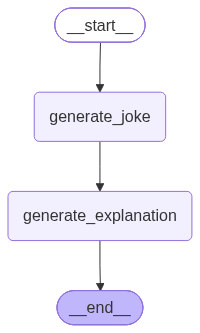

In [6]:
graph_builder = StateGraph(JokeState)

graph_builder.add_node("generate_joke", generate_joke)
graph_builder.add_node("generate_explanation", generate_explanation)

graph_builder.add_edge(START, "generate_joke")
graph_builder.add_edge("generate_joke", "generate_explanation")
graph_builder.add_edge("generate_explanation", END)

checkpointer = InMemorySaver()

graph = graph_builder.compile(checkpointer=checkpointer)
graph

In [7]:
initial_state = {"topic": "goalkeeper"}
config1 = {"configurable": {"thread_id" :"1"}}
graph.invoke(initial_state, config = config1)

{'topic': 'goalkeeper',
 'joke': 'Here\'s one:\n\nWhy did the goalkeeper go to therapy?\n\nBecause he was feeling defensive about his past!\n\nExplanation:\n\nIn a football (soccer) game, a goalkeeper is responsible for defending the goal by preventing the opposing team from scoring. The term "defensive" refers to the act of defending or protecting something.\n\nIn the joke, the goalkeeper is feeling defensive about his past, which means he\'s feeling defensive about something that happened in the past. It\'s a play on words, using the same term that is commonly associated with their job in football, and applying it to a psychological state. The punchline is a clever pun that creates a humorous connection between the goalkeeper\'s profession and their emotional state.',
 'explanation': 'The joke relies on a play on words, using the multiple meanings of the term "defensive". In the context of football, a goalkeeper is defensive, meaning they are protecting their goal from opposing team\

In [8]:
graph.get_state(config = config1)

StateSnapshot(values={'topic': 'goalkeeper', 'joke': 'Here\'s one:\n\nWhy did the goalkeeper go to therapy?\n\nBecause he was feeling defensive about his past!\n\nExplanation:\n\nIn a football (soccer) game, a goalkeeper is responsible for defending the goal by preventing the opposing team from scoring. The term "defensive" refers to the act of defending or protecting something.\n\nIn the joke, the goalkeeper is feeling defensive about his past, which means he\'s feeling defensive about something that happened in the past. It\'s a play on words, using the same term that is commonly associated with their job in football, and applying it to a psychological state. The punchline is a clever pun that creates a humorous connection between the goalkeeper\'s profession and their emotional state.', 'explanation': 'The joke relies on a play on words, using the multiple meanings of the term "defensive". In the context of football, a goalkeeper is defensive, meaning they are protecting their goal 

In [9]:
list(graph.get_state_history(config1))

[StateSnapshot(values={'topic': 'goalkeeper', 'joke': 'Here\'s one:\n\nWhy did the goalkeeper go to therapy?\n\nBecause he was feeling defensive about his past!\n\nExplanation:\n\nIn a football (soccer) game, a goalkeeper is responsible for defending the goal by preventing the opposing team from scoring. The term "defensive" refers to the act of defending or protecting something.\n\nIn the joke, the goalkeeper is feeling defensive about his past, which means he\'s feeling defensive about something that happened in the past. It\'s a play on words, using the same term that is commonly associated with their job in football, and applying it to a psychological state. The punchline is a clever pun that creates a humorous connection between the goalkeeper\'s profession and their emotional state.', 'explanation': 'The joke relies on a play on words, using the multiple meanings of the term "defensive". In the context of football, a goalkeeper is defensive, meaning they are protecting their goal

### Time Travel

In [10]:
graph.get_state({"configurable": {"thread_id" :"1", "checkpoint_id": "1f19ede0-6f9d-66e6-8001-6c4646cbbdcb"}})

StateSnapshot(values={'topic': 'goalkeeper', 'joke': 'Here\'s one:\n\nWhy did the goalkeeper go to therapy?\n\nBecause he was feeling defensive about his past!\n\nExplanation:\n\nIn a football (soccer) game, a goalkeeper is responsible for defending the goal by preventing the opposing team from scoring. The term "defensive" refers to the act of defending or protecting something.\n\nIn the joke, the goalkeeper is feeling defensive about his past, which means he\'s feeling defensive about something that happened in the past. It\'s a play on words, using the same term that is commonly associated with their job in football, and applying it to a psychological state. The punchline is a clever pun that creates a humorous connection between the goalkeeper\'s profession and their emotional state.'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f19ede0-6f9d-66e6-8001-6c4646cbbdcb'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_a

In [11]:
graph.invoke(None, config = {"configurable": {"thread_id" :"1", "checkpoint_id": "1f19ede0-6f9d-66e6-8001-6c4646cbbdcb"}}   )

{'topic': 'goalkeeper',
 'joke': 'Here\'s one:\n\nWhy did the goalkeeper go to therapy?\n\nBecause he was feeling defensive about his past!\n\nExplanation:\n\nIn a football (soccer) game, a goalkeeper is responsible for defending the goal by preventing the opposing team from scoring. The term "defensive" refers to the act of defending or protecting something.\n\nIn the joke, the goalkeeper is feeling defensive about his past, which means he\'s feeling defensive about something that happened in the past. It\'s a play on words, using the same term that is commonly associated with their job in football, and applying it to a psychological state. The punchline is a clever pun that creates a humorous connection between the goalkeeper\'s profession and their emotional state.',
 'explanation': 'The joke is a play on words, using the term "defensive" in a different context than its typical meaning in football. In the joke, the goalkeeper is literally feeling defensive about his past, but the wo

In [15]:
list(graph.get_state_history((config1)))

[StateSnapshot(values={'topic': 'goalkeeper', 'joke': 'Here\'s one:\n\nWhy did the goalkeeper go to therapy?\n\nBecause he was feeling defensive about his past!\n\nExplanation:\n\nIn a football (soccer) game, a goalkeeper is responsible for defending the goal by preventing the opposing team from scoring. The term "defensive" refers to the act of defending or protecting something.\n\nIn the joke, the goalkeeper is feeling defensive about his past, which means he\'s feeling defensive about something that happened in the past. It\'s a play on words, using the same term that is commonly associated with their job in football, and applying it to a psychological state. The punchline is a clever pun that creates a humorous connection between the goalkeeper\'s profession and their emotional state.', 'explanation': 'The joke is a play on words, using the term "defensive" in a different context than its typical meaning in football. In the joke, the goalkeeper is literally feeling defensive about 

### Updating State

In [18]:
graph.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f19ede0-51dc-655b-8000-b3053a13c0a3", "checkpoint_ns": ""}}, {'topic':'Football'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19edf0-2936-6976-8001-10dadb24a4bb'}}

In [19]:
list(graph.get_state_history(config1))

[StateSnapshot(values={'topic': 'Football'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19edf0-2936-6976-8001-10dadb24a4bb'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-23T10:40:08.330687+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19ede0-51dc-655b-8000-b3053a13c0a3'}}, tasks=(PregelTask(id='bc4f6e1c-d835-6516-19b9-6010ec129ef1', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'goalkeeper', 'joke': 'Here\'s one:\n\nWhy did the goalkeeper go to therapy?\n\nBecause he was feeling defensive about his past!\n\nExplanation:\n\nIn a football (soccer) game, a goalkeeper is responsible for defending the goal by preventing the opposing team from scoring. The term "defensive" refers to the act of defending or protecting someth

### Fault Tolerance

In [7]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [8]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [9]:

# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

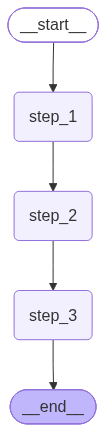

In [14]:
graph

In [10]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [12]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [13]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f19f2cc-b14f-60f0-8003-5d11a632dec2'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-23T19:56:55.972068+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f19f2cc-b14b-66f6-8002-f3c0d35f5911'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f19f2cc-b14b-66f6-8002-f3c0d35f5911'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-23T19:56:55.970584+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f19f2c9-b90b-62e4-8001-c12a9a865c51'}}, tasks=(PregelTask(id='046f6316-624c-5934-e164-b455b518f61